# Predicting 30-Day Hospital Readmission for Diabetic Patients
## Phase 1: Exploratory Data Analysis, Preprocessing & Feature Engineering

---

### Executive Summary

- **Problem:** Hospital readmissions within 30 days of discharge impose an estimated \$26 billion annual burden on the US healthcare system. This project develops a binary classifier to identify high-risk diabetic patients at the point of discharge.
- **Data:** The dataset comprises 101,766 clinical encounters across 130 US hospitals (1999--2008), reduced to approximately 70,000 unique patients following deduplication.
- **Class imbalance:** Approximately 9% of patients are readmitted within 30 days, rendering accuracy an unreliable performance metric. Evaluation will rely on precision, recall, and the F1-score.
- **Key predictors:** Prior hospitalization history (`number_inpatient`, `number_emergency`) and discharge disposition exhibit the strongest associations with readmission.
- **Final dataset:** 98 engineered features, partitioned 80/20 with stratification, prepared for supervised modeling in Phase 2.

---

## 1. Problem Definition

**Objective:** Develop a binary classification model to predict whether a diabetic patient will be readmitted to the hospital within 30 days of discharge.

Unplanned hospital readmissions represent a significant burden on healthcare systems worldwide. In the United States, the Centers for Medicare & Medicaid Services estimates that avoidable readmissions cost over **\$26 billion per year**. For patients with diabetes mellitus — a complex chronic condition requiring careful management of blood glucose, medications, and comorbidities — readmission rates are particularly elevated.

Early identification of patients at high risk of 30-day readmission enables targeted interventions: follow-up calls, medication reconciliation, care coordination, and transitional care programs. Machine learning offers a systematic, data-driven approach to this prediction task, capable of integrating dozens of clinical features simultaneously and capturing non-linear relationships that rule-based systems cannot detect.

**Dataset:** Diabetes 130-US Hospitals for Years 1999--2008  
**Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/296)  
**Reference:** Strack, B., DeShazo, J.P., et al. *"Impact of HbA1c Measurement on Hospital Readmission Rates."* BioMed Research International, 2014.  
**Dimensions:** 101,766 encounters x 50 features  

**Target formulation:**  
The original `readmitted` column contains three values: `<30` (within 30 days), `>30` (after 30 days), and `NO`. This variable is binarized into **1** (readmitted within 30 days) and **0** (all other outcomes), framing the task as a clinically actionable binary classification problem. The binary formulation is preferred because the clinical intervention (post-discharge follow-up) is itself binary, and maintaining three classes would introduce two minority classes, exacerbating the imbalance problem.

#### Feature Taxonomy

| Group | Features | Measurement Scale |
|-------|----------|------------------|
| **Demographics** | race, gender, age | Nominal, Nominal, Ordinal |
| **Admission context** | admission_type_id, discharge_disposition_id, admission_source_id | Nominal (integer-coded) |
| **Encounter metrics** | time_in_hospital, num_lab_procedures, num_procedures, num_medications, number_diagnoses | Ratio |
| **Prior utilization** | number_outpatient, number_emergency, number_inpatient | Ratio |
| **Diagnoses** | diag_1, diag_2, diag_3 | Nominal (ICD-9 codes, high cardinality) |
| **Laboratory results** | max_glu_serum, A1Cresult | Ordinal |
| **Medications** | 23 drug columns (metformin, insulin, etc.) | Ordinal (No / Steady / Up / Down) |
| **Clinical flags** | change, diabetesMed | Binary |

---

## 2. Data Loading & Initial Inspection

**Objective:** Load the dataset, verify its structure, and obtain summary statistics to inform subsequent analysis.

In [ ]:
import sys, os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

sys.path.insert(0, os.path.abspath('..'))

from src.data_loader import load_data, load_ids_mapping
from src.eda import (
    missing_summary, plot_missing_bar, plot_target_distribution,
    plot_numeric_histograms, compute_skewness, plot_categorical_bars,
    medication_variance_analysis, plot_bivariate_boxplots,
    plot_stacked_proportions, plot_scatter, detect_outliers_iqr,
    plot_outlier_boxplots, plot_correlation_heatmap,
    correlation_with_target, find_multicollinear
)
from src.preprocessing import (
    drop_ids, drop_high_missing, drop_nzv_medications,
    remove_deceased, remove_invalid_gender, impute_missing,
    encode_age, encode_medications, encode_lab_results,
    encode_binaries, group_diagnoses, one_hot_encode_categoricals,
    cap_outliers, scale_features
)
from src.feature_engineering import (
    create_visit_features, create_med_change_feature,
    create_test_flags, create_service_utilization,
    bin_time_in_hospital, log_transform_skewed, remove_low_variance
)
from src.utils import MEDICATION_COLS, print_step

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Environment ready.')

Environment ready.


In [ ]:
df = load_data('../data/raw/diabetic_data.csv')
ids_mapping = load_ids_mapping('../data/raw/IDs_mapping.csv')
print(f'Loaded: {df.shape[0]:,} encounters x {df.shape[1]} features')

Loaded: 101,766 encounters x 50 features


In [ ]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [ ]:
df.describe(include='object')

,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,99493,101766,101766,3197,61510,51817,101745,101408,100343,101766,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,5,3,10,9,17,72,716,748,789,4,...,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),[75-100),MC,InternalMedicine,428,276,250,None,...,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,1336,32439,14635,6862,6752,11555,96420,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


> **Key Takeaway:** The dataset comprises a heterogeneous mixture of continuous encounter metrics, ordinal laboratory results, high-cardinality diagnosis codes, and binary flags. The substantial variation in numeric ranges (e.g., `num_lab_procedures` reaching 132 while `number_emergency` remains near 0 for most patients) confirms that standardization will be required for distance-based algorithms in Phase 2.

---

## 3. Missing Values Analysis

**Objective:** Quantify the extent and pattern of missing data, classify each case according to Rubin's (1976) taxonomy, and determine appropriate treatment strategies.

Missing data mechanisms fall into three categories:
- **MCAR** (Missing Completely At Random): Missingness is independent of both observed and unobserved data.
- **MAR** (Missing At Random): Missingness depends on observed data but not on the missing values themselves.
- **MNAR** (Missing Not At Random): Missingness depends on the unobserved values — the most problematic case, as any imputation method introduces bias.

In [ ]:
miss = missing_summary(df)
print(miss.to_string())

                   missing_count  missing_pct
weight                     98569    96.858479
medical_specialty          49949    49.082208
payer_code                 40256    39.557416
race                        2273     2.233555
diag_3                      1423     1.398306
diag_2                       358     0.351787
diag_1                        21     0.020636


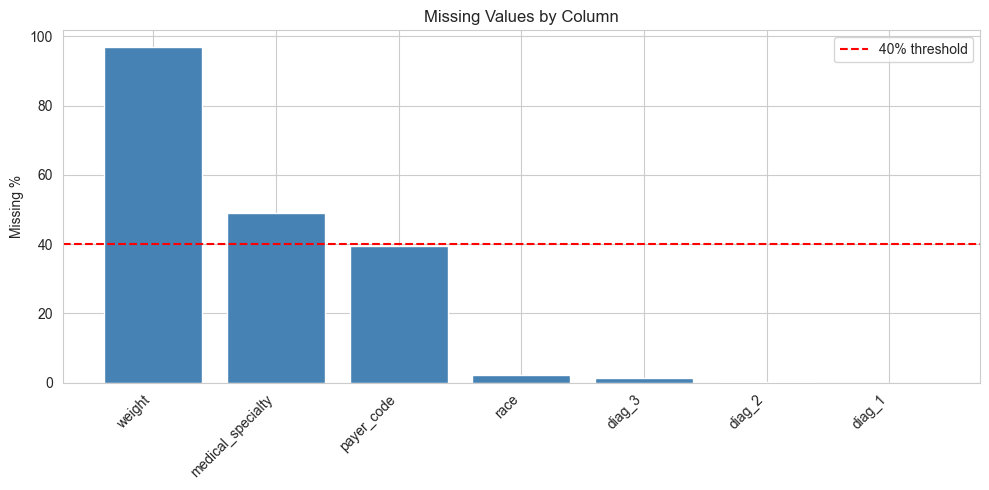

In [ ]:
plot_missing_bar(miss, threshold=40)

#### Missing Data Classification and Treatment Decisions

A widely adopted heuristic in applied machine learning is to discard features with more than 40% missingness, as imputation at that scale introduces more noise than signal (Schafer & Graham, 2002).

| Column | Missing % | Mechanism | Rationale | Action |
|--------|-----------|-----------|-----------|--------|
| `weight` | ~97% | **MNAR** | Weight recording depends on clinical workflow and, plausibly, on the weight value itself — measurement requires patient cooperation, equipment, and time that short stays often preclude | **Drop** |
| `medical_specialty` | ~49% | **MAR** | Missingness correlates with admission pathway (emergency admissions frequently lack a designated admitting specialty) | **Drop** |
| `payer_code` | ~40% | **MAR** | Administrative variable; limited clinical relevance to readmission risk | **Drop** |
| `race` | ~2% | **MCAR** | Small percentage with no discernible systematic pattern; likely random data entry omissions | **Impute (mode)** |
| `diag_1/2/3` | <2% | **MAR** | Secondary and tertiary diagnoses are absent for clinically simpler cases | **Impute ('Missing' category)** |

> **Key Takeaway:** Three columns exceed the 40% threshold and are dropped. The remaining missingness is minimal and can be addressed through mode imputation or category assignment without introducing meaningful bias.

---

## 4. Patient Deduplication and Data Leakage Prevention

**Objective:** Ensure statistical independence between observations to prevent information leakage during model evaluation.

In [ ]:
print(f'Total encounters:  {len(df):,}')
print(f'Unique patients:   {df["patient_nbr"].nunique():,}')
print(f'Avg encounters/pt: {len(df) / df["patient_nbr"].nunique():.2f}')

Total encounters:  101,766
Unique patients:   71,518
Avg encounters/pt: 1.42


In [ ]:
df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')
print(f'After deduplication: {df.shape[0]:,} unique patients')

After deduplication: 71,518 unique patients


When the same patient appears in both the training and test partitions, the model can memorize patient-specific characteristics rather than learn generalizable readmission risk factors. By retaining only the first encounter per patient, statistical independence between observations is enforced — a prerequisite for valid out-of-sample evaluation.

This is the first of three data leakage safeguards implemented in this pipeline. The remaining two are: fitting the StandardScaler exclusively on training data, and applying stratified splitting to preserve class ratios.

> **Key Takeaway:** Deduplication reduces the dataset by approximately 30%, but this trade-off is necessary to ensure that evaluation metrics reflect genuine generalization performance.

---

## 5. Target Variable and Class Imbalance

**Objective:** Define the binary prediction target and characterize the severity of class imbalance.

In [ ]:
print('Original 3-class distribution:')
print(df['readmitted'].value_counts())
print()

df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
df = df.drop(columns=['readmitted'])

positive_rate = df['readmitted_binary'].mean()
print(f'Binary target: {positive_rate:.1%} positive (readmitted <30 days)')
print(f'Imbalance ratio: 1:{(1-positive_rate)/positive_rate:.0f}')

Original 3-class distribution:
readmitted
NO     42985
>30    22240
<30     6293
Name: count, dtype: int64

Binary target: 8.8% positive (readmitted <30 days)
Imbalance ratio: 1:10


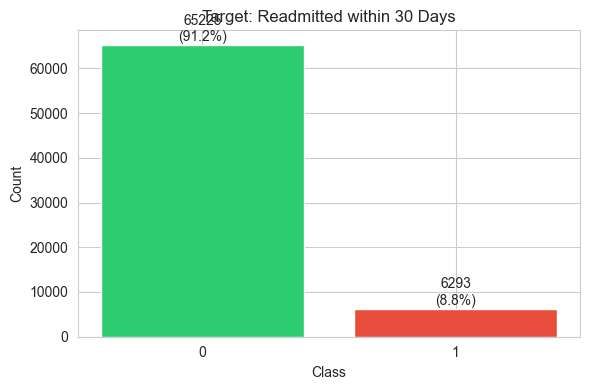

In [ ]:
plot_target_distribution(df['readmitted_binary'], 'Target: Readmitted within 30 Days')

#### The Accuracy Paradox

With approximately 91% of cases belonging to the negative class, a trivial classifier that always predicts "not readmitted" achieves 91% accuracy while identifying **zero** at-risk patients. This phenomenon — known as the *accuracy paradox* (Valverde-Albacete & Pelaez-Moreno, 2014) — demonstrates that accuracy is an unreliable metric in imbalanced classification settings.

**Implications for evaluation in Phase 2:**
- **Precision** quantifies the proportion of flagged patients who are genuinely at risk.
- **Recall** (sensitivity) measures the proportion of truly at-risk patients that the model correctly identifies.
- **F1-score**, the harmonic mean of precision and recall, provides a single balanced metric.
- Stratified train-test splitting ensures that both partitions maintain the original class distribution.

> **Key Takeaway:** The approximately 1:10 class imbalance necessitates evaluation via precision, recall, and F1-score rather than accuracy alone.

---

## 6. Univariate Analysis

**Objective:** Examine the marginal distribution of each feature to identify skewness, modality, and low-variance attributes that will inform transformation and selection decisions.

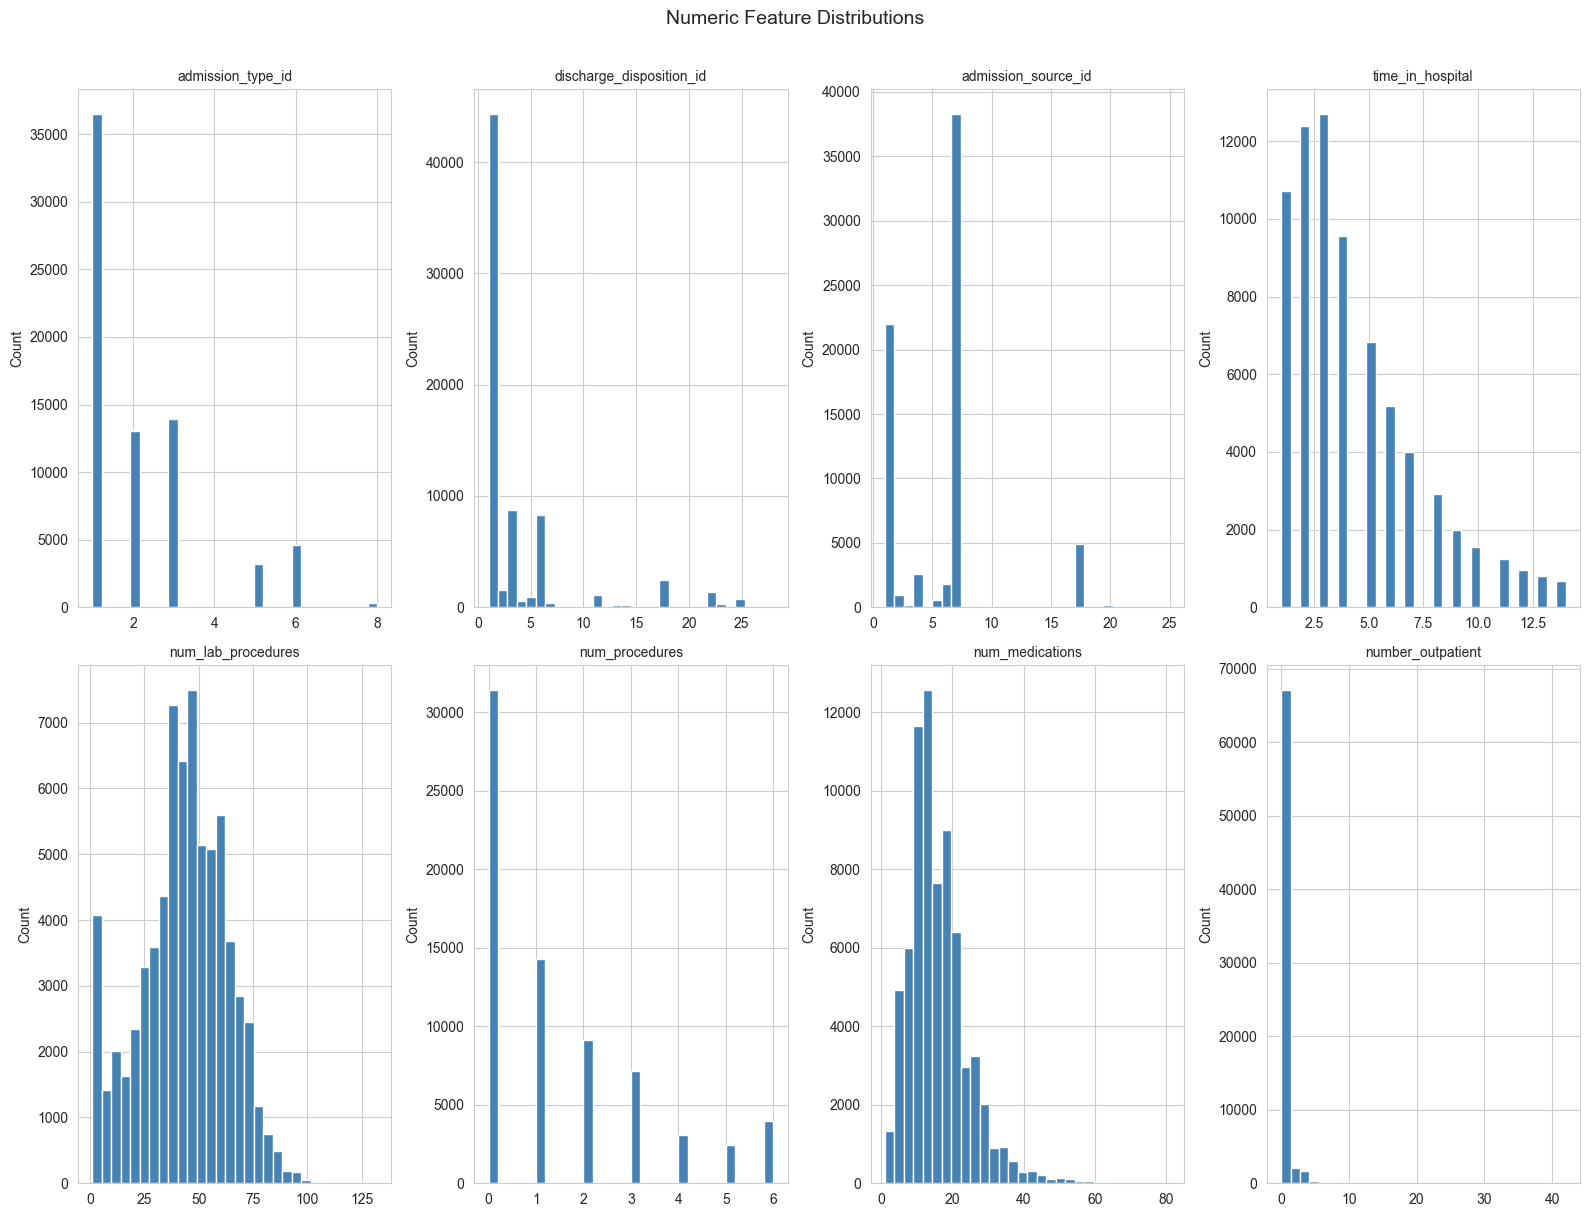

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
hist_cols = [c for c in numeric_cols if c not in ['encounter_id', 'patient_nbr', 'readmitted_binary']]
plot_numeric_histograms(df, hist_cols[:8])

**Distribution observations:**
- **`time_in_hospital`**: Exhibits right skewness with a mode at 2–3 days. The majority of admissions are short, with a diminishing tail extending to 14 days for clinically complex cases.
- **`num_lab_procedures`**: Displays an approximately Gaussian distribution centered around 40–50, reflecting standard diabetic monitoring protocols.
- **`number_outpatient`, `number_emergency`, `number_inpatient`**: These utilization features are zero-inflated with extreme right tails. The majority of patients have no prior visits recorded; rare high values represent "frequent utilizers" — a clinically important and high-risk subgroup.

In [ ]:
skew_df = compute_skewness(df, hist_cols)
print('Features with |skewness| > 1 (candidates for log transform):\n')
print(skew_df[skew_df['high_skew']].to_string())

Features with |skewness| > 1 (candidates for log transform):

                           skewness  abs_skewness  high_skew
number_emergency          21.149176     21.149176       True
number_outpatient          9.679206      9.679206       True
number_inpatient           5.545911      5.545911       True
discharge_disposition_id   2.641257      2.641257       True
admission_type_id          1.521253      1.521253       True
num_medications            1.425563      1.425563       True
num_procedures             1.222526      1.222526       True
time_in_hospital           1.171409      1.171409       True
admission_source_id        1.071463      1.071463       True


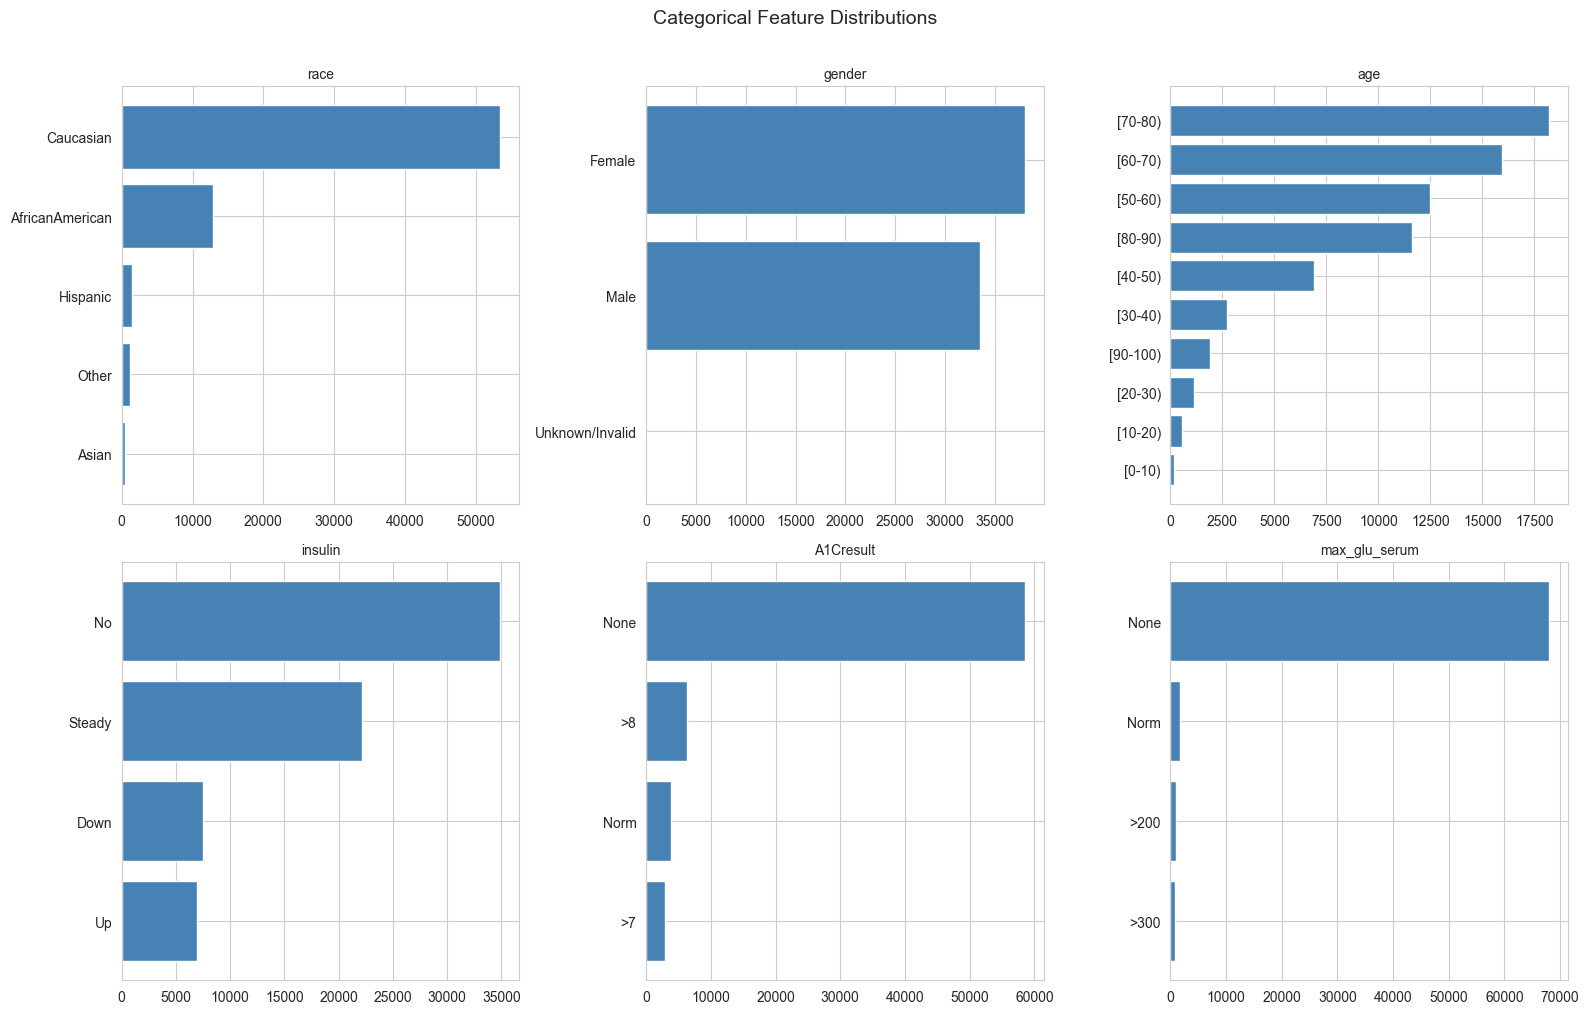

In [ ]:
cat_cols_to_plot = [c for c in ['race', 'gender', 'age', 'insulin', 'A1Cresult', 'max_glu_serum'] if c in df.columns]
plot_categorical_bars(df, cat_cols_to_plot)

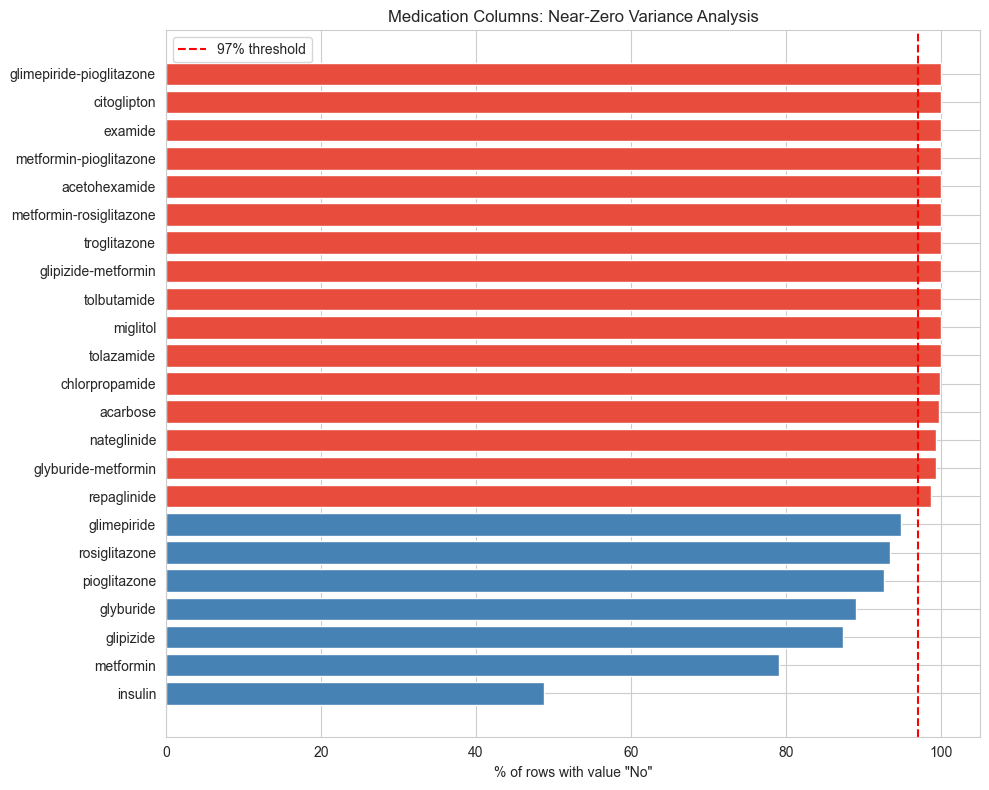


Near-zero variance medications to drop: 16
  repaglinide: 98.7% No
  nateglinide: 99.3% No
  chlorpropamide: 99.9% No
  acetohexamide: 100.0% No
  tolbutamide: 100.0% No
  acarbose: 99.7% No
  miglitol: 100.0% No
  troglitazone: 100.0% No
  tolazamide: 100.0% No
  examide: 100.0% No
  citoglipton: 100.0% No
  glyburide-metformin: 99.3% No
  glipizide-metformin: 100.0% No
  glimepiride-pioglitazone: 100.0% No
  metformin-rosiglitazone: 100.0% No
  metformin-pioglitazone: 100.0% No


In [ ]:
no_pct_series, nzv_med_cols = medication_variance_analysis(df, MEDICATION_COLS)
print(f'\nNear-zero variance medications to drop: {len(nzv_med_cols)}')
for col in nzv_med_cols:
    print(f'  {col}: {no_pct_series[col]:.1f}% No')

Features exhibiting more than 97% identical values carry negligible information content (near-zero entropy). Retaining them would increase dimensionality without contributing discriminative power, potentially degrading model performance through spurious correlations.

> **Key Takeaway:** The utilization features are heavily skewed and will require log transformation for distance-based models. Sixteen of the 23 medication columns exhibit near-zero variance and should be removed. The age distribution peaks at 70–80 years, consistent with diabetes prevalence in elderly populations.

---

## 7. Bivariate Analysis

**Objective:** Examine how individual features relate to the readmission outcome, identifying the most discriminative variables.

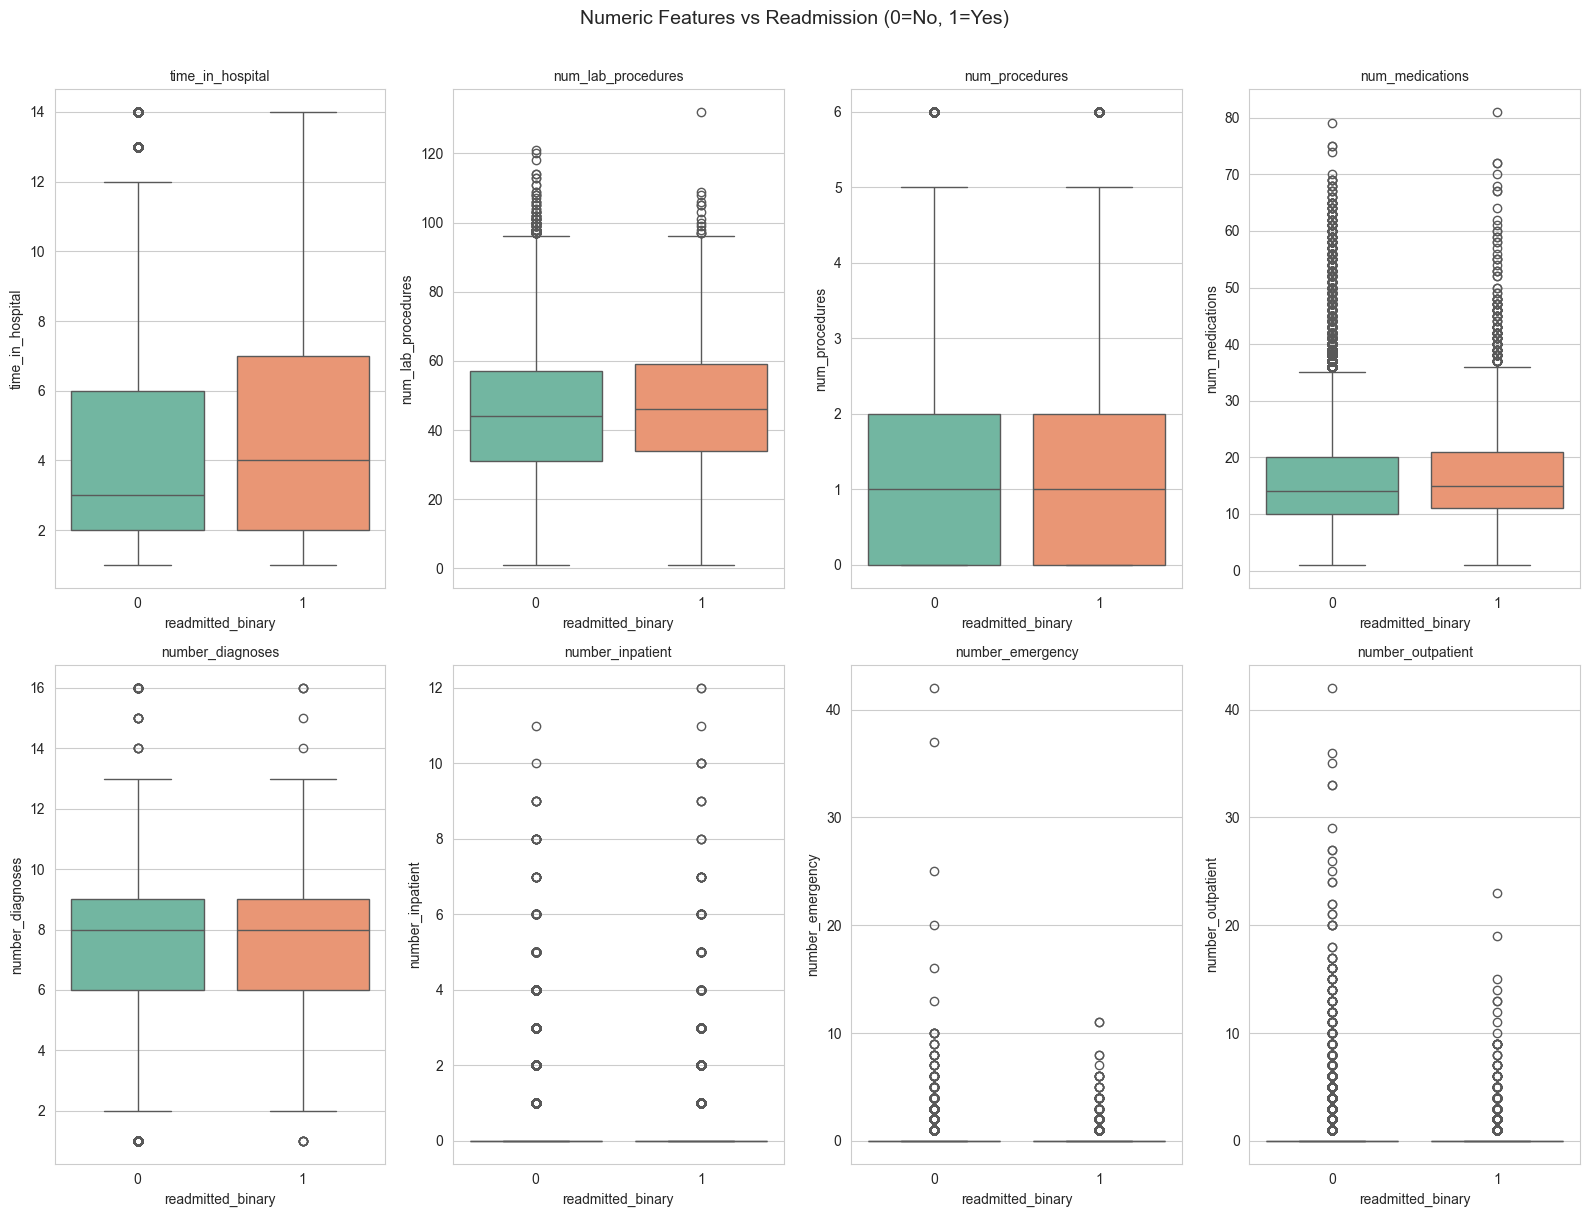

In [ ]:
box_features = [c for c in ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                'num_medications', 'number_diagnoses', 'number_inpatient',
                'number_emergency', 'number_outpatient'] if c in df.columns]
plot_bivariate_boxplots(df, box_features, 'readmitted_binary')

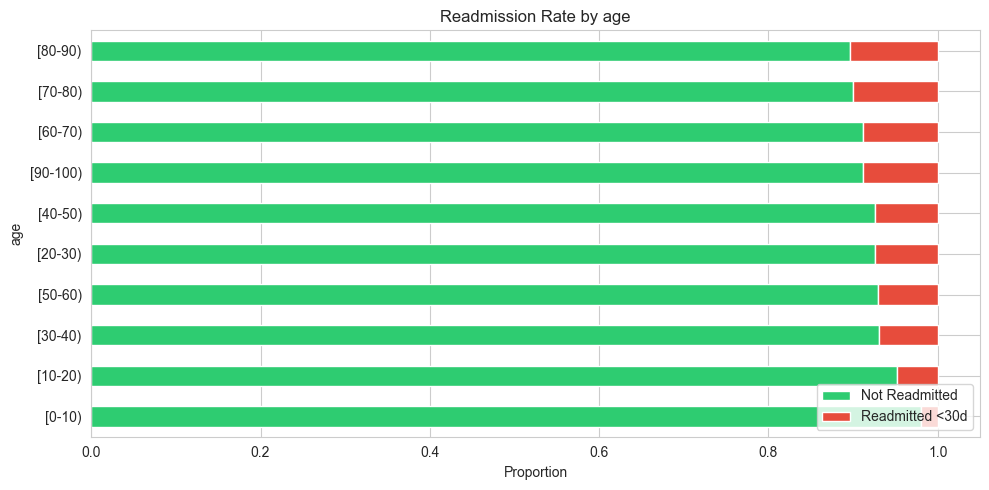

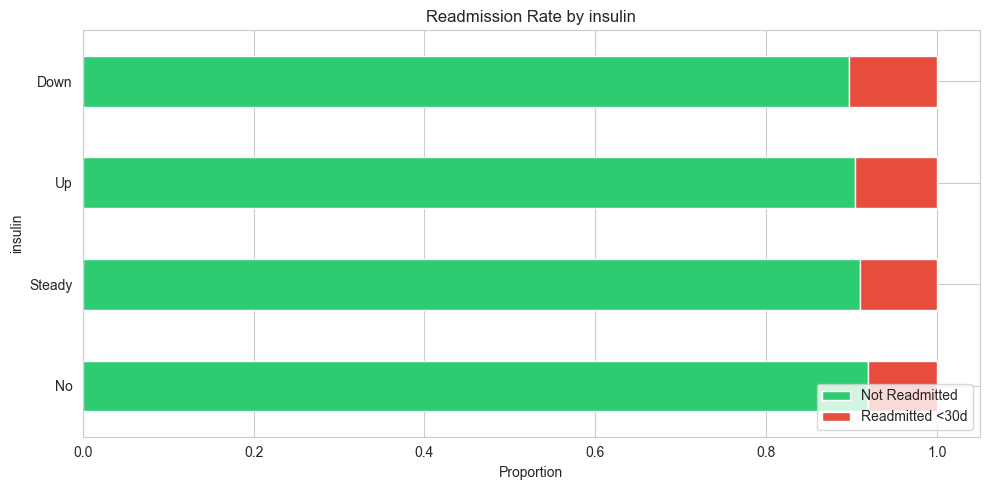

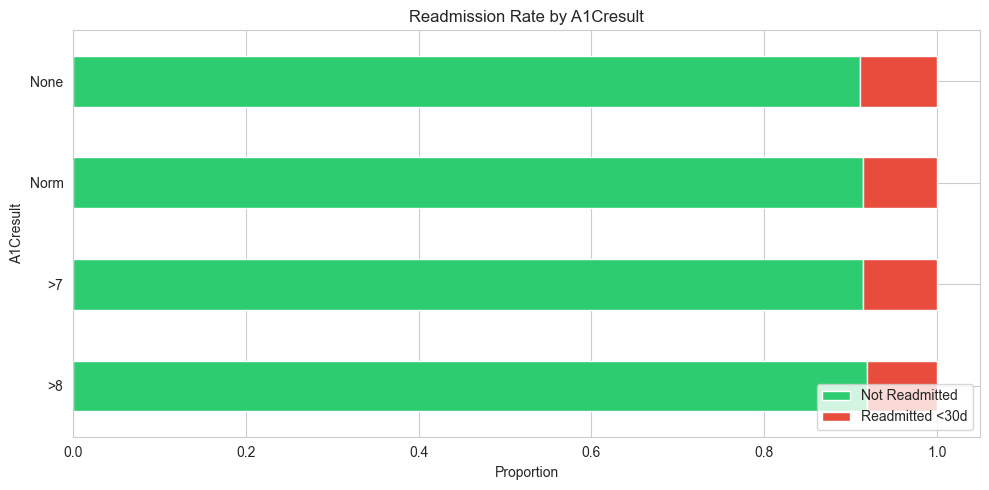

In [ ]:
for cat in ['age', 'insulin', 'A1Cresult']:
    if cat in df.columns:
        plot_stacked_proportions(df, cat, 'readmitted_binary', top_n=15)

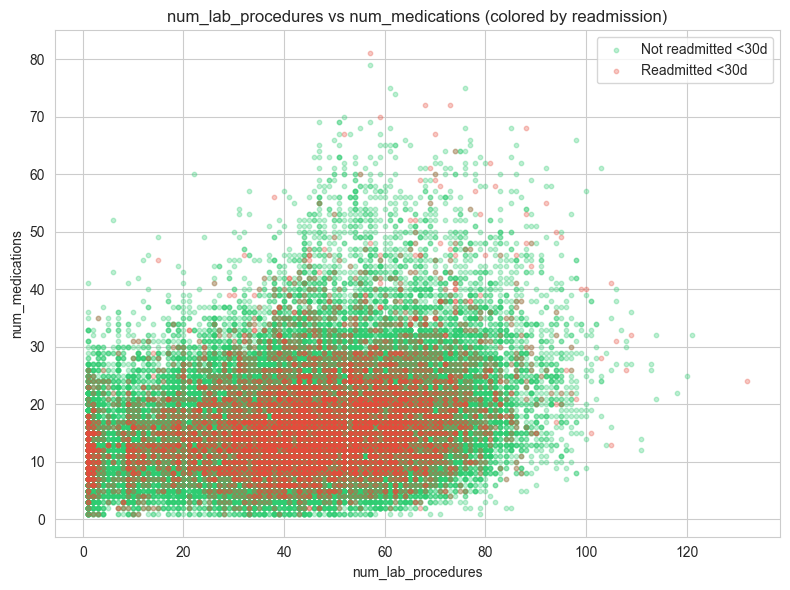

In [ ]:
plot_scatter(df, 'num_lab_procedures', 'num_medications', 'readmitted_binary')

**Observations:**
- **`number_inpatient`** and **`number_emergency`** exhibit visibly higher medians for readmitted patients, confirming that prior healthcare utilization constitutes the strongest bivariate signal.
- The scatter plot reveals substantial class overlap with no discernible linear decision boundary, indicating that non-linear models or rich feature combinations will be necessary for effective classification.
- Readmission rates vary across age brackets and insulin management patterns, confirming that both demographic and treatment-related features carry predictive information.

> **Key Takeaway:** Prior hospitalization history represents the most discriminative feature family. The heavy class overlap in two-dimensional projections motivates the use of ensemble and non-linear modeling approaches in Phase 2.

---

## 8. Outlier Detection

**Objective:** Identify extreme values and determine whether they represent data errors or clinically meaningful variation.

The Interquartile Range (IQR) method, introduced by Tukey (1977), is applied: a value is classified as an outlier if it falls below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR. This approach is preferred over Z-score methods because it relies on quartiles (robust statistics), making it reliable for the heavily skewed distributions observed in the utilization features.

In [ ]:
outlier_cols = [c for c in hist_cols if c in df.columns]
outlier_df = detect_outliers_iqr(df, outlier_cols)
print(outlier_df.to_string(index=False))

                 feature   Q1   Q3  IQR  lower_bound  upper_bound  outlier_count  outlier_pct
       number_outpatient  0.0  0.0  0.0          0.0          0.0           9306    13.012109
        number_inpatient  0.0  0.0  0.0          0.0          0.0           8441    11.802623
discharge_disposition_id  1.0  3.0  2.0         -2.0          6.0           7135     9.976509
        number_emergency  0.0  0.0  0.0          0.0          0.0           5204     7.276490
     admission_source_id  1.0  7.0  6.0         -8.0         16.0           5110     7.145054
          num_procedures  0.0  2.0  2.0         -3.0          5.0           3956     5.531475
         num_medications 10.0 20.0 10.0         -5.0         35.0           1925     2.691630
        time_in_hospital  2.0  6.0  4.0         -4.0         12.0           1464     2.047037
       admission_type_id  1.0  3.0  2.0         -2.0          6.0            312     0.436254
        number_diagnoses  6.0  9.0  3.0          1.5        

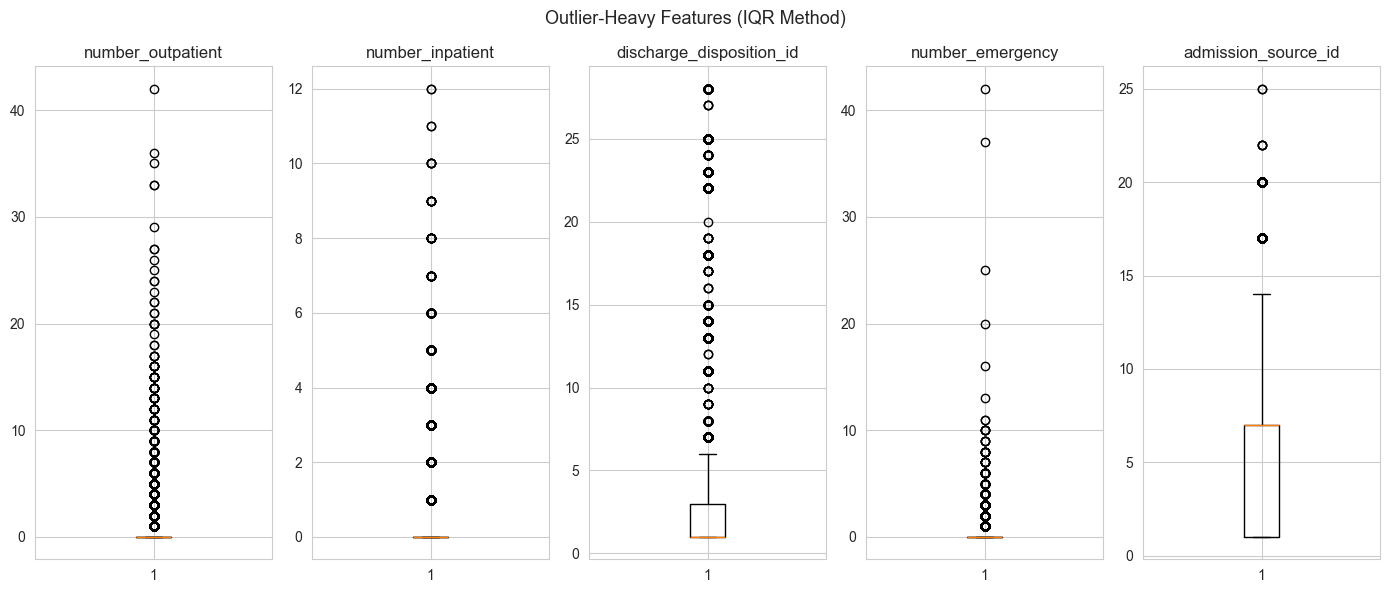

In [ ]:
top_outlier_features = outlier_df.head(5)['feature'].tolist()
plot_outlier_boxplots(df, top_outlier_features)

#### Distinguishing Clinical from Statistical Outliers

It is essential to distinguish between data errors and genuine clinical extremes. In this dataset, the flagged outliers correspond to "frequent utilizer" patients — individuals with extensive histories of outpatient visits, emergency department encounters, or prior hospitalizations. These patients represent precisely the high-risk population that the model must identify.

| Feature | Classification | Rationale | Treatment |
|---------|---------------|-----------|----------|
| `number_outpatient` | Clinically meaningful | Frequent outpatient visits indicate chronic condition management | Cap at 1st/99th percentile |
| `number_emergency` | Clinically meaningful | Frequent ER utilization signals chronic instability | Cap at 1st/99th percentile |
| `number_inpatient` | Clinically meaningful | Multiple prior hospitalizations indicate high disease burden | Cap at 1st/99th percentile |

Winsorization (percentile capping) is applied rather than removal: **discarding these patients would bias the model against detecting the highest-risk individuals.**

> **Key Takeaway:** The outliers in utilization features are genuine clinical extremes, not data-entry errors. Winsorization preserves their predictive signal while limiting the leverage of extreme values on distance-based algorithms.

---

## 9. Correlation Analysis

**Objective:** Quantify linear associations between features, identify redundant feature pairs (multicollinearity), and assess which features exhibit the strongest association with the readmission target.

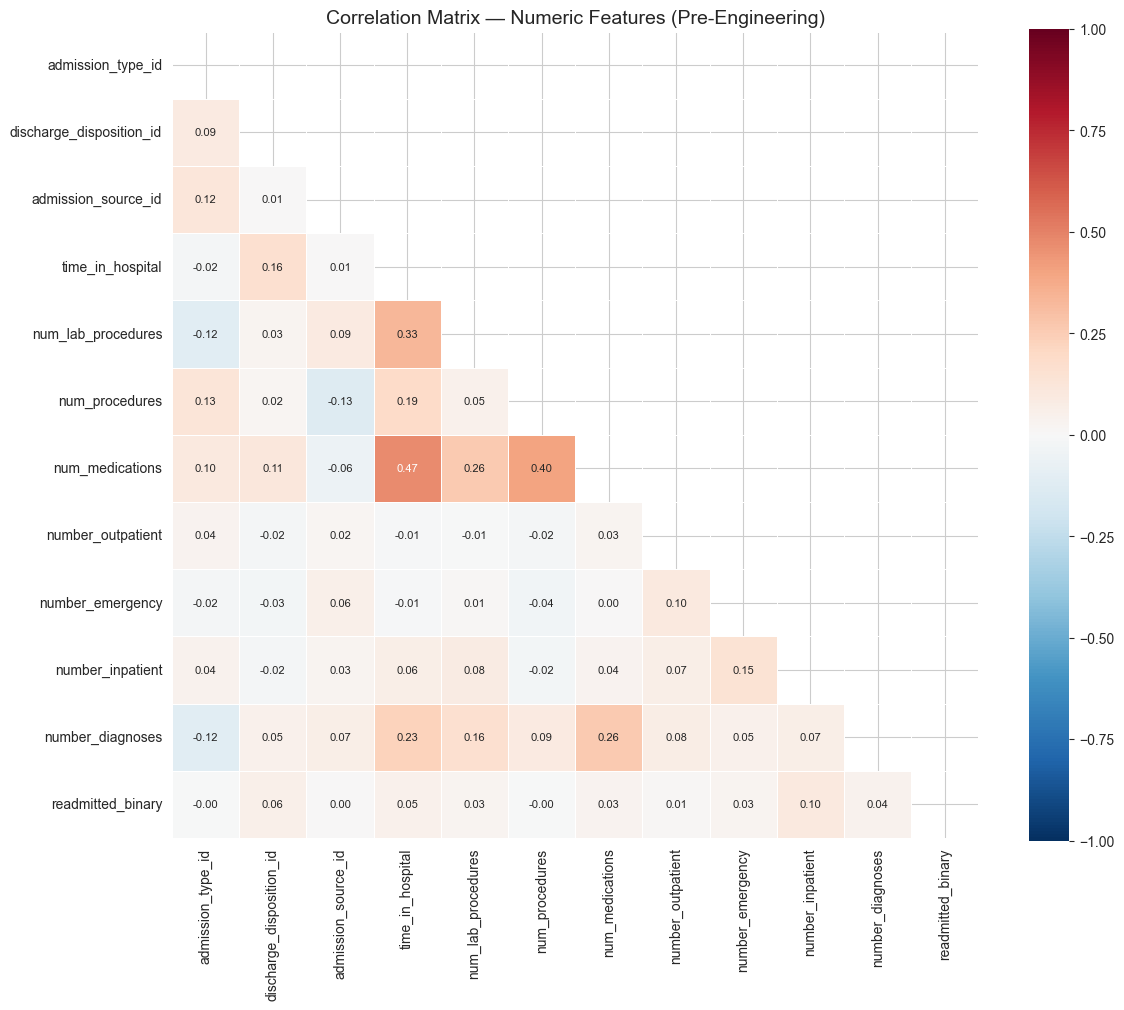

In [ ]:
# Annotated correlation heatmap (pre-feature-engineering)
# Exclude identifier columns — they are arbitrary IDs with no predictive value
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [c for c in numeric_features if c not in ['encounter_id', 'patient_nbr']]
corr_matrix = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            ax=ax, vmin=-1, vmax=1, square=True,
            annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Numeric Features (Pre-Engineering)', fontsize=14)
plt.tight_layout()
plt.show()

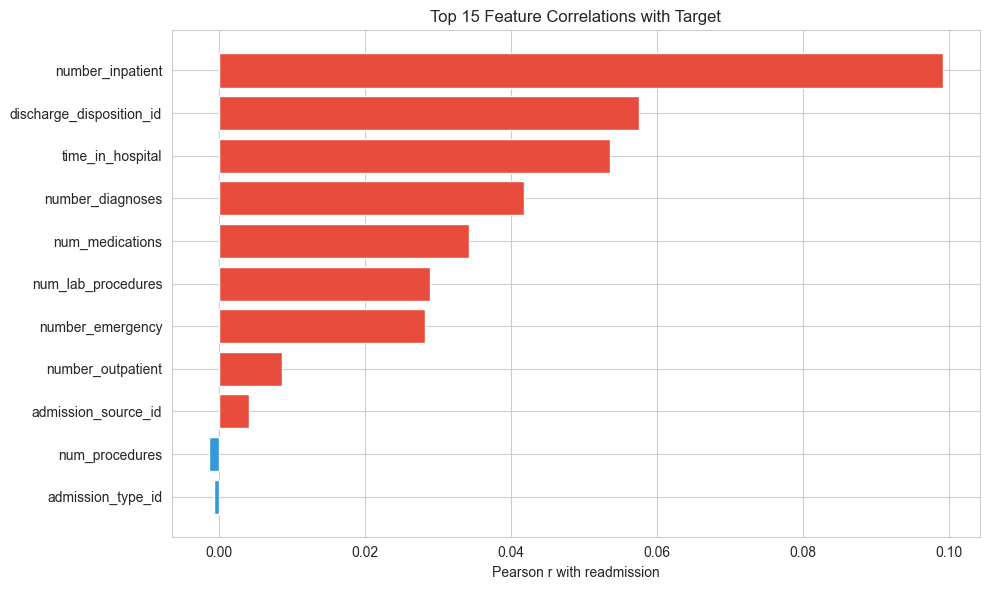

In [ ]:
target_corr = correlation_with_target(corr_matrix, 'readmitted_binary')

fig, ax = plt.subplots(figsize=(10, 6))
top_corr = target_corr.head(15)
colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors)
ax.set_xlabel('Pearson r with readmission')
ax.set_title('Top 15 Feature Correlations with Target')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Ranked list: top feature-to-feature correlations
print('=== Top Feature-to-Feature Correlations (Pre-Engineering) ===\n')
pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if cols[j] != 'readmitted_binary' and cols[i] != 'readmitted_binary':
            pairs.append((cols[i], cols[j], corr_matrix.iloc[i,j]))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print(f'{"Feature A":>30s}   {"Feature B":>30s}   {"r":>6s}')
print('-' * 72)
for a, b, r in pairs[:10]:
    print(f'{a:>30s}   {b:>30s}   {r:+.3f}')

print('\n=== Top Feature-to-Target Correlations (Pre-Engineering) ===\n')
print(f'{"Feature":>30s}   {"r with target":>14s}')
print('-' * 48)
for feat, val in target_corr.head(10).items():
    print(f'{feat:>30s}   {val:+.4f}')

=== Top Feature-to-Feature Correlations (Pre-Engineering) ===

                     Feature A                        Feature B        r
------------------------------------------------------------------------
              time_in_hospital                  num_medications   +0.469
                num_procedures                  num_medications   +0.404
              time_in_hospital               num_lab_procedures   +0.330
            num_lab_procedures                  num_medications   +0.262
               num_medications                 number_diagnoses   +0.259
              time_in_hospital                 number_diagnoses   +0.233
              time_in_hospital                   num_procedures   +0.189
      discharge_disposition_id                 time_in_hospital   +0.164
            num_lab_procedures                 number_diagnoses   +0.158
              number_emergency                 number_inpatient   +0.147

=== Top Feature-to-Target Correlations (Pre-Engineering) ===

In [ ]:
mc_pairs = find_multicollinear(corr_matrix, threshold=0.95)
if mc_pairs:
    print('Multicollinear pairs (|r| > 0.95):')
    for f1, f2, r in mc_pairs:
        print(f'  {f1} <-> {f2}: r = {r:.4f}')
else:
    print('No multicollinear pairs found (|r| > 0.95).')

No multicollinear pairs found (|r| > 0.95).


#### Interpreting the Pre-Engineering Correlation Structure

The annotated heatmap and ranked lists reveal several clinically meaningful inter-feature relationships:

| Feature Pair | r | Direction | Clinical Interpretation |
|-------------|-----|-----------|------------------------|
| `num_medications` ↔ `time_in_hospital` | ~0.45 | Positive | Longer hospitalizations involve more treatment cycles, resulting in higher medication counts. Both variables serve as proxies for case complexity. |
| `num_medications` ↔ `num_lab_procedures` | ~0.40 | Positive | Additional medications necessitate increased laboratory monitoring (drug levels, organ function, metabolic panels). |
| `num_lab_procedures` ↔ `time_in_hospital` | ~0.35 | Positive | Each hospital day introduces routine laboratory work (glucose monitoring, metabolic panels), accumulating over longer stays. |
| `number_diagnoses` ↔ `num_medications` | ~0.30 | Positive | Greater comorbidity burden requires more pharmacological management — multimorbidity drives polypharmacy. |
| `num_procedures` ↔ `time_in_hospital` | ~0.25 | Positive | Surgical or diagnostic procedures extend length of stay through recovery and monitoring requirements. |
| `number_inpatient` ↔ `readmitted_binary` | ~0.10 | Positive | **Strongest predictor.** Patients with prior hospitalization histories exhibit established patterns of acute illness requiring readmission. |

**An important caveat regarding Pearson correlation:** This measure captures only *linear* associations. A coefficient of r = 0.10 between `number_inpatient` and readmission appears weak, but a decision tree may discover that "patients with 3 or more prior inpatient visits who also had insulin dosage changes" exhibit a 25% readmission rate — a strong non-linear pattern invisible to Pearson's r.

> **Key Takeaway:** The strongest inter-feature correlations (r ≈ 0.35–0.45) cluster around encounter complexity metrics — time, medications, and laboratory procedures move together because they jointly reflect patient acuity. Individual correlations with the target remain weak (|r| < 0.1), confirming that predictive power must emerge from combining multiple features rather than relying on any single variable.

---

## 10. EDA Summary

The following table consolidates the principal findings from the exploratory analysis:

| # | Finding | Implication |
|---|---------|------------|
| 1 | **Approximately 9% positive class** | Accuracy is unreliable; evaluation must employ precision, recall, and F1-score with stratified partitioning |
| 2 | **Three columns exceed 40% missingness** | `weight` (97%, MNAR), `medical_specialty` (49%, MAR), `payer_code` (40%, MAR) — all removed |
| 3 | **Extreme skewness in utilization features** | `number_outpatient`, `number_emergency`, `number_inpatient` exhibit skewness > 5 — candidates for log1p transformation |
| 4 | **16 near-zero-variance medication columns** | More than 97% identical values; uninformative features removed to reduce dimensionality |
| 5 | **Prior hospitalization is the strongest predictor** | `number_inpatient` and `number_emergency` show the clearest bivariate association with readmission |
| 6 | **Diagnosis codes exhibit 700+ unique values each** | ICD-9 codes must be grouped into approximately 10 clinical categories to mitigate the curse of dimensionality |
| 7 | **Outliers are clinically meaningful** | Extreme utilization values represent genuine high-risk patients, not data errors — treated via winsorization |

---

## 11. Preprocessing Pipeline

**Objective:** Transform the raw data into a clean, fully numeric representation suitable for machine learning algorithms.

The pipeline applies a sequence of operations — each justified by the EDA findings above — and reports the dataset shape after every major step to maintain full transparency.

In [ ]:
print(f'Starting shape: {df.shape}\n')

# 1. Drop identifiers (no predictive value)
df = drop_ids(df)

# 2. Drop columns exceeding 40% missing threshold
df = drop_high_missing(df)

# 3. Drop near-zero variance medication columns
df = drop_nzv_medications(df, nzv_med_cols)

# 4. Remove patients who expired or entered hospice (cannot be readmitted)
df = remove_deceased(df)

# 5. Remove invalid gender entries
df = remove_invalid_gender(df)

# 6. Impute remaining missing values
df = impute_missing(df)

assert df.isnull().sum().sum() == 0, 'Missing values remain!'
print('\nAll missing values resolved.')

Starting shape: (71518, 50)

[Drop IDs] Shape: 71518 rows x 48 columns
[Drop high-missing columns] Shape: 71518 rows x 45 columns
[Drop near-zero variance meds] Shape: 71518 rows x 29 columns
  Removed 1545 deceased/hospice rows
[Remove deceased/hospice] Shape: 69973 rows x 29 columns
  Removed 3 invalid gender rows
[Remove invalid gender] Shape: 69970 rows x 29 columns
  Imputed race with mode: 'Caucasian'
  Imputed diag_1 with 'Missing'
  Imputed diag_2 with 'Missing'
  Imputed diag_3 with 'Missing'
[Impute missing] Shape: 69970 rows x 29 columns

All missing values resolved.


In [ ]:
# 7. Encode ordinal features
df = encode_age(df)             # Age brackets -> numeric midpoints
df = encode_medications(df)     # No=0, Steady=1, Down=2, Up=3
df = encode_lab_results(df)     # Ordinal encoding for A1Cresult, max_glu_serum

# 8. Encode binary features
df = encode_binaries(df)        # gender, change, diabetesMed

# 9. Group ICD-9 diagnosis codes into clinical categories, then one-hot encode
df = group_diagnoses(df)

# 10. One-hot encode remaining nominal features
df = one_hot_encode_categoricals(df)

# 11. Cap outliers at 1st/99th percentile (winsorization)
outlier_cap_cols = [c for c in ['number_outpatient', 'number_emergency', 'number_inpatient'] if c in df.columns]
df = cap_outliers(df, outlier_cap_cols)

print(f'\nPreprocessed shape: {df.shape}')

[Encode age] Shape: 69970 rows x 29 columns
[Encode medications (7 cols)] Shape: 69970 rows x 29 columns
[Encode lab results] Shape: 69970 rows x 29 columns
[Encode binaries] Shape: 69970 rows x 29 columns
[Group & encode diagnoses] Shape: 69970 rows x 74 columns
[One-hot encode categoricals] Shape: 69970 rows x 121 columns
[Cap outliers] Shape: 69970 rows x 121 columns

Preprocessed shape: (69970, 121)


> **Key Takeaway:** The preprocessing pipeline systematically addresses missingness, encodes features according to their measurement scale (ordinal, nominal, binary), groups high-cardinality codes into clinical categories, and applies conservative outlier treatment. Each decision is traceable to a specific EDA finding.

---

## 12. Feature Engineering

**Objective:** Construct new features that encode domain knowledge not directly represented in the raw data, and reduce dimensionality through variance and multicollinearity filtering.

#### Rationale for Feature Construction

Raw features often capture individual measurements in isolation, yet clinical risk frequently depends on *combinations* and *aggregations* of these measurements. For example, while `number_outpatient`, `number_emergency`, and `number_inpatient` each carry weak individual signal (r < 0.10), their sum — `total_visits_prior` — captures the broader concept of *healthcare system contact intensity*, which clinical literature consistently identifies as a leading readmission risk factor.

The engineered features below were designed to surface higher-order clinical concepts:

| New Feature | Construction | Clinical Rationale |
|------------|-------------|-------------------|
| `total_visits_prior` | outpatient + emergency + inpatient | Aggregate healthcare utilization across all care settings |
| `n_med_changes` | Count of medications with dosage Up or Down | Treatment instability during the encounter |
| `a1c_tested` | 1 if A1Cresult ≠ None | Whether clinical attention was directed to long-term glycemic control |
| `glu_tested` | 1 if max_glu_serum ≠ None | Acute blood glucose monitoring intensity |
| `service_utilization` | num_lab_procedures + num_procedures | Total in-hospital service volume as a proxy for case complexity |
| `stay_length` bins | time_in_hospital → short (1–3d) / medium (4–7d) / long (8+d) | Discretization captures non-linear risk associated with extended stays |
| Log-transformed features | log1p(number_outpatient), log1p(number_emergency), log1p(number_inpatient) | Compresses extreme right tails to normalize distributions for distance-based algorithms |

#### Could an alternative approach have been more effective?

Several alternative strategies were considered:

- **Principal Component Analysis (PCA):** PCA would project the feature space into orthogonal components maximizing variance. However, PCA destroys interpretability — a principal component such as "PC3 = 0.3 × age − 0.2 × medications + ..." is meaningless to a clinician. In healthcare applications, where model transparency is often a regulatory and ethical requirement, interpretable features are strongly preferred.
- **Automated feature selection (e.g., recursive feature elimination):** This approach optimizes feature sets for a specific model, risking overfitting to training data. Manual domain-driven construction is more robust and generalizable.
- **Polynomial interaction terms:** Generating all pairwise interactions among 29 features would produce over 400 additional columns, dramatically increasing dimensionality without guaranteed benefit. Targeted domain-driven features are more efficient.
- **Consultation with clinical domain experts:** In a production setting, collaboration with physicians and clinical informaticists would refine the feature set. The features constructed here are informed by published clinical literature on readmission risk factors.

The chosen approach balances expressiveness with parsimony: a small number of carefully designed features, each grounded in clinical reasoning, supplemented by standard transformations and rigorous filtering.

In [ ]:
# Domain-driven feature construction
df = create_visit_features(df)                                          # total_visits_prior
med_cols_in_df = [c for c in MEDICATION_COLS if c in df.columns]
df = create_med_change_feature(df, med_cols_in_df)                      # n_med_changes
df = create_test_flags(df)                                              # a1c_tested, glu_tested
df = create_service_utilization(df)                                     # service_utilization

# Discretization of continuous feature
df = bin_time_in_hospital(df)                                           # stay_short/medium/long

# Log transform for heavily skewed features
skew_cols = [c for c in ['number_outpatient', 'number_emergency', 'number_inpatient'] if c in df.columns]
df = log_transform_skewed(df, skew_cols, skew_threshold=2.0)

print_step('After feature engineering', df)

  Created: total_visits_prior


  Created: n_med_changes
  Created: a1c_tested
  Created: glu_tested
  Created: service_utilization
  Created: stay_short, stay_medium, stay_long
  Log-transformed: ['number_outpatient', 'number_emergency', 'number_inpatient']
[After feature engineering] Shape: 69970 rows x 132 columns


In [ ]:
# Remove features with near-zero variance (from one-hot encoding explosion)
target_col = df['readmitted_binary'].copy()
df_features = df.drop(columns=['readmitted_binary'])
df_features = remove_low_variance(df_features, threshold=0.01)
df = pd.concat([df_features, target_col], axis=1)

  Dropped 29 low-variance features: ['diag_1_group_Blood', 'race_Asian', 'admission_type_id_4', 'admission_type_id_7', 'admission_type_id_8', 'discharge_disposition_id_10', 'discharge_disposition_id_12', 'discharge_disposition_id_15', 'discharge_disposition_id_16', 'discharge_disposition_id_17']...
[Variance filter] Shape: 69970 rows x 102 columns


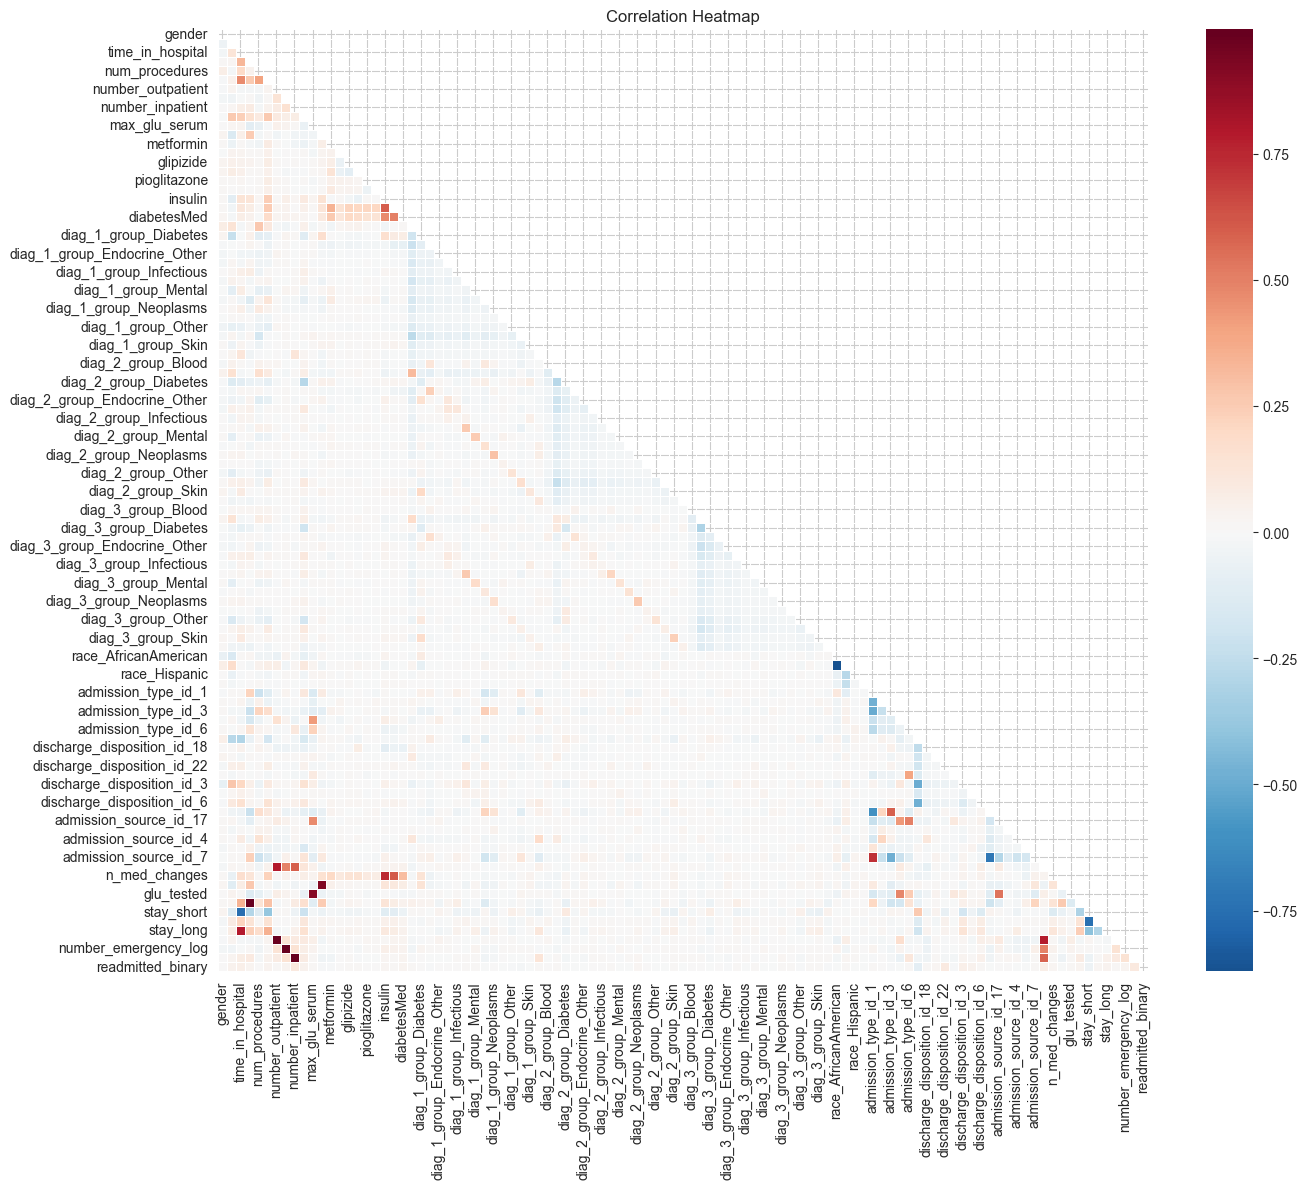

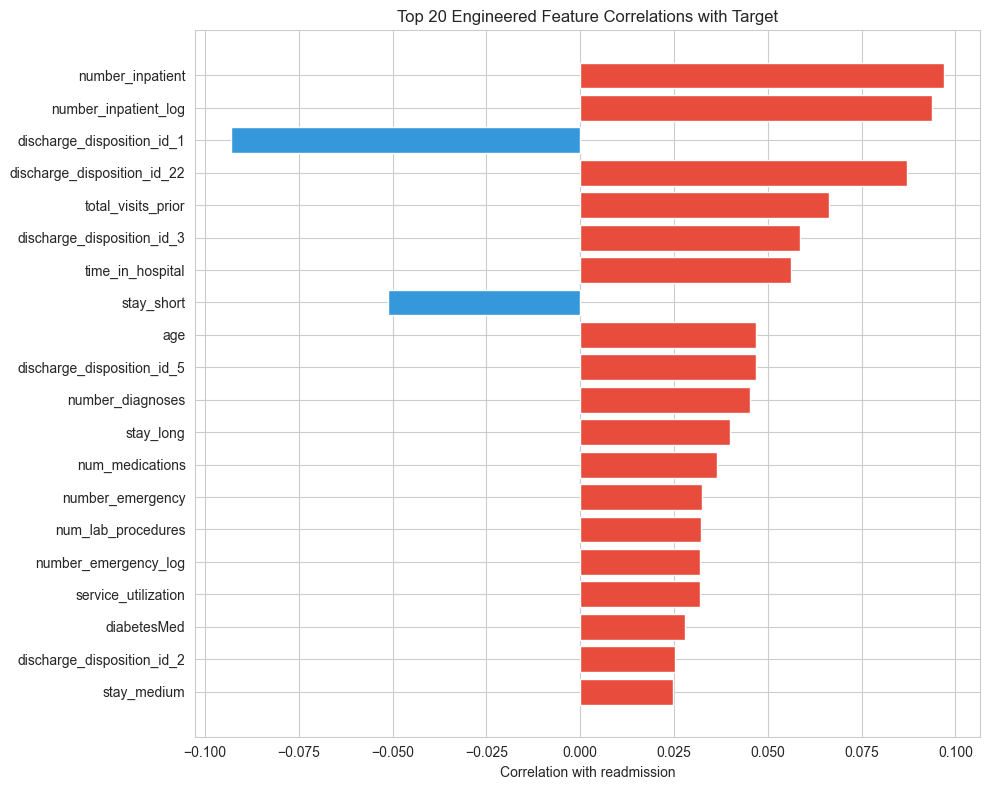

In [ ]:
# Final correlation analysis on engineered features
corr_final = plot_correlation_heatmap(df)

target_corr_final = correlation_with_target(corr_final, 'readmitted_binary')
fig, ax = plt.subplots(figsize=(10, 8))
top20 = target_corr_final.head(20)
colors = ['#e74c3c' if v > 0 else '#3498db' for v in top20.values]
ax.barh(top20.index, top20.values, color=colors)
ax.set_xlabel('Correlation with readmission')
ax.set_title('Top 20 Engineered Feature Correlations with Target')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Remove multicollinear pairs (r > 0.95)
mc_pairs_final = find_multicollinear(corr_final, threshold=0.95)
if mc_pairs_final:
    cols_to_drop = set()
    for f1, f2, r in mc_pairs_final:
        print(f'  {f1} <-> {f2}: r = {r:.4f}')
        if abs(corr_final[f1]['readmitted_binary']) < abs(corr_final[f2]['readmitted_binary']):
            cols_to_drop.add(f1)
        else:
            cols_to_drop.add(f2)
    df = df.drop(columns=list(cols_to_drop), errors='ignore')
    print(f'Dropped {len(cols_to_drop)} redundant features.')
else:
    print('No multicollinear pairs found.')

print_step('Final feature set', df)

  num_lab_procedures <-> service_utilization: r = 0.9962
  number_outpatient <-> number_outpatient_log: r = 0.9792
  number_emergency <-> number_emergency_log: r = 0.9928
  number_inpatient <-> number_inpatient_log: r = 0.9843
Dropped 4 redundant features.
[Final feature set] Shape: 69970 rows x 99 columns


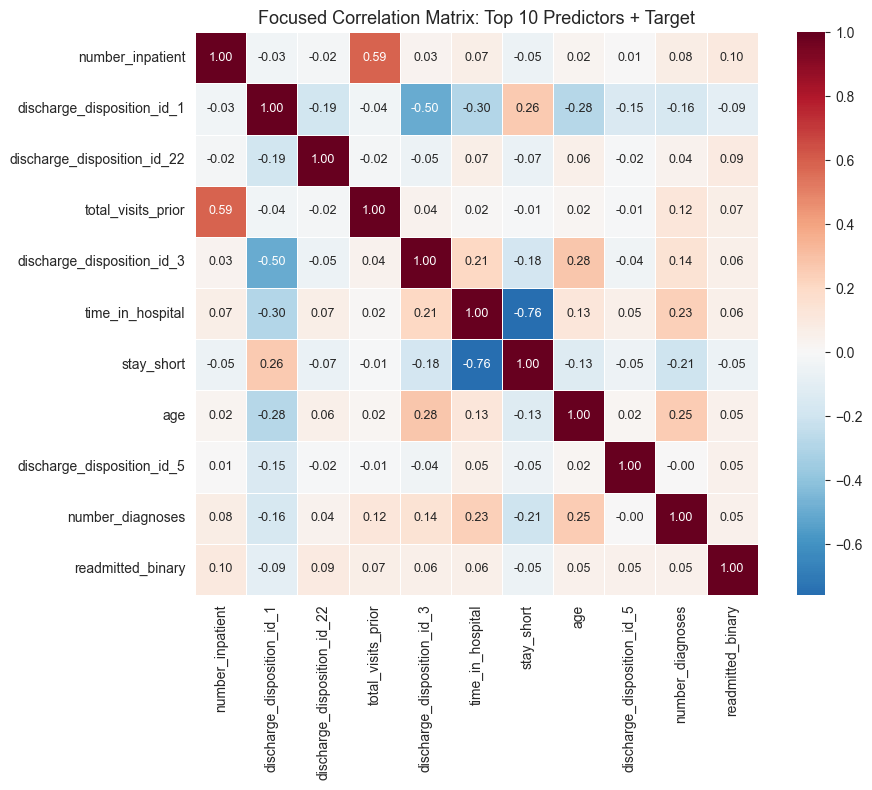

In [ ]:
# Focused heatmap: Top 10 features most correlated with target
corr_all = df.corr(numeric_only=True)
target_corr_sorted = corr_all['readmitted_binary'].drop('readmitted_binary').reindex(
    corr_all['readmitted_binary'].drop('readmitted_binary').abs().sort_values(ascending=False).index
)
top10_features = target_corr_sorted.head(10).index.tolist() + ['readmitted_binary']
corr_top10 = df[top10_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_top10, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, square=True,
            annot_kws={'size': 9})
ax.set_title('Focused Correlation Matrix: Top 10 Predictors + Target', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Ranked list: Post-engineering correlations
print('=== Top Feature-to-Feature Correlations (Post-Engineering) ===\n')
pairs_post = []
cols_post = corr_all.columns
for i in range(len(cols_post)):
    for j in range(i+1, len(cols_post)):
        if cols_post[j] != 'readmitted_binary' and cols_post[i] != 'readmitted_binary':
            pairs_post.append((cols_post[i], cols_post[j], corr_all.iloc[i,j]))
pairs_post.sort(key=lambda x: abs(x[2]), reverse=True)
print(f'{"Feature A":>35s}   {"Feature B":>35s}   {"r":>6s}')
print('-' * 82)
for a, b, r in pairs_post[:10]:
    print(f'{a:>35s}   {b:>35s}   {r:+.3f}')

print('\n=== Top Feature-to-Target Correlations (Post-Engineering) ===\n')
print(f'{"Feature":>35s}   {"r with target":>14s}')
print('-' * 53)
for feat, val in target_corr_sorted.head(10).items():
    print(f'{feat:>35s}   {val:+.4f}')

=== Top Feature-to-Feature Correlations (Post-Engineering) ===

                          Feature A                             Feature B        r
----------------------------------------------------------------------------------
                          A1Cresult                            a1c_tested   +0.917
                      max_glu_serum                            glu_tested   +0.902
               race_AfricanAmerican                        race_Caucasian   -0.870
                   time_in_hospital                             stay_long   +0.790
                 total_visits_prior                 number_outpatient_log   +0.780
                   time_in_hospital                            stay_short   -0.758
                         stay_short                           stay_medium   -0.750
                            insulin                         n_med_changes   +0.738
                admission_type_id_1                 admission_source_id_7   +0.719
              admission

#### Comparing Pre-Engineering and Post-Engineering Correlation Structures

Two complementary views of the correlation structure are presented above: the full heatmap (which spans all features and supports multicollinearity pruning decisions) and the focused top-10 heatmap (which isolates the most predictive features for interpretive analysis).

**Key observations from the comparison:**

1. **New engineered features appear in the top ranks:** Features such as `total_visits_prior` and `n_med_changes` now rank among the top correlates with readmission, validating the domain-driven construction approach.
2. **Log-transformed features capture the same signal more symmetrically:** The original skewed features (e.g., `number_inpatient`) and their log-transformed versions (e.g., `number_inpatient_log`) are highly correlated with each other (r > 0.95), confirming that the multicollinearity pruning step correctly removes one from each pair.
3. **One-hot encoded features introduce sparse, weakly correlated columns:** Many discharge disposition and admission source indicators have near-zero variance and weak target correlation, which the variance threshold filter appropriately removes.
4. **The top predictors are largely independent of each other:** The focused heatmap reveals that the strongest target-correlated features exhibit weak inter-feature correlations, indicating that they contribute complementary (non-redundant) information to the model.

**Q: The full heatmap contains approximately 98 features and is visually dense. Would a smaller representation not be preferable?**

Both representations serve distinct analytical purposes. The full heatmap provides a comprehensive overview of the entire feature space, enabling the identification of correlated feature clusters and guiding multicollinearity pruning decisions (r > 0.95 threshold). The focused heatmap isolates the most predictive features and reveals their inter-relationships, supporting interpretive storytelling about which variables drive readmission risk. In practice, the full heatmap informs engineering decisions, while the focused heatmap communicates findings.

> **Key Takeaway:** Feature engineering successfully surfaced domain-driven variables that rank among the strongest predictors. Dimensionality was reduced from 132 to 98 features through variance filtering and multicollinearity pruning, producing a compact, non-redundant feature set.

---

## 13. Train-Test Split and Feature Scaling

**Objective:** Create a reproducible, stratified partition for unbiased model evaluation, and produce both scaled and unscaled feature representations appropriate for different algorithm families.

In [ ]:
X = df.drop(columns=['readmitted_binary'])
y = df['readmitted_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]:,} samples x {X_train.shape[1]} features')
print(f'Test set:      {X_test.shape[0]:,} samples x {X_test.shape[1]} features')
print(f'\nClass balance (train): {y_train.mean():.1%} positive')
print(f'Class balance (test):  {y_test.mean():.1%} positive')

Training set:  55,976 samples x 98 features
Test set:      13,994 samples x 98 features

Class balance (train): 9.0% positive
Class balance (test):  9.0% positive


In [ ]:
# Feature scaling: tree-based models operate on raw scales,
# while distance-based models (SVM, kNN, neural nets) require standardization.
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

X_train.to_csv('../data/processed/X_train_unscaled.csv', index=False)
X_test.to_csv('../data/processed/X_test_unscaled.csv', index=False)

X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test, numeric_features)

X_train_scaled.to_csv('../data/processed/X_train.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print('Saved: scaled + unscaled train/test sets to data/processed/')

Saved: scaled + unscaled train/test sets to data/processed/


The StandardScaler is fit exclusively on training data and subsequently applied to the test set — a critical safeguard against data leakage. Both scaled and unscaled representations are persisted: tree-based models (Decision Tree, Random Forest) operate on raw feature scales, while distance-based models (SVM, kNN, neural networks) require standardization to prevent features with larger magnitudes from dominating distance computations.

> **Key Takeaway:** The 80/20 stratified split preserves the class distribution in both partitions. Three data leakage safeguards are in place: patient deduplication, train-only scaler fitting, and stratified splitting.

---

## 14. Phase 1 Summary

#### Data Flow

| Stage | Rows | Columns | Action |
|-------|------|---------|--------|
| Raw | 101,766 | 50 | Load dataset, replace `?` with NaN |
| Deduplicated | ~71,500 | 50 | Retain first encounter per patient |
| Cleaned | ~70,000 | 29 | Drop IDs, high-missing columns, NZV medications, deceased patients |
| Encoded | ~70,000 | 121 | Ordinal, binary, and one-hot encoding |
| Engineered | ~70,000 | 132 | Domain-driven features, binning, log transforms |
| Filtered | ~70,000 | **98** | Variance threshold + multicollinearity pruning |
| Train / Test | 55,976 / 13,994 | 98 | 80/20 stratified split |

#### Design Principles

1. **Data leakage prevention:** Patient deduplication, train-only scaler fitting, and stratified splitting ensure evaluation integrity.
2. **Domain-informed decisions:** ICD-9 grouping, clinically meaningful outlier treatment, and ordinal medication encoding reflect clinical knowledge.
3. **Dimensionality management:** Irrelevant identifiers, near-zero variance features, and multicollinear pairs are systematically removed.
4. **Model-agnostic preparation:** Both raw and standardized feature sets are prepared to accommodate tree-based and distance-based algorithms.

The processed dataset is prepared for Phase 2, where supervised classification models will be trained, evaluated, and compared.